# Model Training Notebook Template

> **Purpose:** Use this notebook to document the full machine learning model development process for your project.  
> It is designed as a **deliverable template** for the task and can be adapted for classification, regression, forecasting, recommendation, anomaly detection, or clustering problems.

---

## How to use this notebook
1. Duplicate this notebook for your project.
2. Rename the notebook model_training_notebook_<student_number>.ipynb
3. Replace all placeholders marked with `TODO`.
4. Keep the narrative concise but evidence-based.
5. Record each important experiment, metric, and decision.
6. Make sure the final notebook clearly shows:
   - the problem being solved
   - the data used
   - the baseline
   - the models tried
   - evaluation and validation
   - error analysis
   - iterations and improvements
   - the final recommendation and business value
7. Make sure the final notebook is saved in your individual GitHub repo.
8. Make sure the notebook meets the [notebook submission guidelines](https://adsai.buas.nl/General/NotebookSubmissionRules.html).

---

## Deliverable alignment
This notebook is structured to support the required deliverable:

- **Model training notebook**
- Evidence for:
  - **ILO 8.4 A:** why the model is an appropriate solution
  - **ILO 8.4 B:** metrics, validation performance, limitations, and common errors
  - **ILO 8.4 C:** key iterations and how they improved performance

## Individual Deliverable

Note this notebook should be completed individually. Each member of the group is responsible for training and analysing their own model. You are free to choose which model or models your team chooses to integrate into your application.
This submission should be unique if your submission is too similar to other members of your group or the class your case will be assessed for academic dishonesty and may be referred to the BOE.


## 0. Project metadata

Fill in this section before starting.

- **Project title:** `TODO`
- **Notebook owner / author:** `TODO`


## 1. Problem definition

### 1.1 Prediction or analysis task
Describe the specific problem your model will solve.

**Template prompts**
- What is the prediction or analysis task?
- What input data is available at prediction time?
- What output should the model produce?
- Who will use the model or its outputs?

**Write-up**
> TODO

### 1.2 Business or project value
Explain why solving this problem matters.

**Template prompts**
- What decision will this model support?
- What is improved if the model works well?
- What risks exist if it performs poorly?

**Write-up**
> TODO

### 1.3 Success criteria
Define what “good enough” means for this project.

**Template prompts**
- Which metric matters most and why?
- What threshold or comparative improvement would count as success?
- What constraints matter besides accuracy (e.g. interpretability, latency, fairness, recall, cost)?

**Write-up**
> TODO


## 2. Data selection and preparation

Document where the data came from, how it was prepared, and any key limitations. If you use multiple datasets you need to discuss all of them here.

### 2.1 Dataset summary
- **Data source(s):** `TODO`
- **Collection period:** `TODO`
- **Unit of analysis:** `TODO`  
  Example: one customer, one transaction, one image, one day, one text sample
- **Target variable:** `TODO`
- **Key features:** `TODO`
- **Important exclusions or filters:** `TODO`

### 2.2 Risks and limitations
- Missing values: `TODO`
- Sampling bias: `TODO`
- Label quality issues: `TODO`
- Leakage risks: `TODO`
- Ethical/privacy concerns: `TODO`


In [107]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas_market_calendars as mcal

pd.set_option('display.max_columns', None)
df = pd.read_csv('../../../data/processed/msft_merged.csv')

### 2.3 Initial data inspection

Summarise the dataset datasets after loading it.

- Number of rows: `TODO`
- Number of columns: `TODO`
- Target class balance / target distribution: `TODO`
- Data types overview: `TODO`
- Key issues noticed in the raw data: `TODO`


In [108]:
print(df.shape)
print(df.info())
df.head()

(2818, 10)
<class 'pandas.DataFrame'>
RangeIndex: 2818 entries, 0 to 2817
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        2818 non-null   str    
 1   Open        2818 non-null   float64
 2   High        2818 non-null   float64
 3   Low         2818 non-null   float64
 4   Close       2818 non-null   float64
 5   Volume      2818 non-null   float64
 6   gold_close  2818 non-null   float64
 7   oil_close   2818 non-null   float64
 8   vix         2818 non-null   float64
 9   spy_close   2818 non-null   float64
dtypes: float64(9), str(1)
memory usage: 220.3 KB
None


,Date,Open,High,Low,Close,Volume,gold_close,oil_close,vix,spy_close
0,2015-02-17,43.97,44.0000,43.19,43.580,33695149.0,1208.099976,53.529999,15.80,174.000732
1,2015-02-18,43.63,43.7000,43.39,43.530,27111657.0,1199.699951,52.139999,15.45,174.017288
2,2015-02-19,43.18,43.5263,43.05,43.500,27556420.0,1207.099976,51.160000,15.29,173.893082
3,2015-02-20,43.51,43.8800,43.29,43.855,29721133.0,1204.400024,50.340000,14.30,174.936493
4,2015-02-23,43.70,44.1900,43.65,44.150,32518754.0,1200.300049,49.450001,14.56,174.911667


In [109]:
# include rows with date only past January 1, 2024
df = df[df['Date'] >= '2015-01-01']
print(df.shape)

(2818, 10)


In [110]:
# Align dataset dates (date-only) with calendar trading days
df["Date"] = pd.to_datetime(df["Date"]).dt.normalize()
df = df.sort_values("Date")

calendar = mcal.get_calendar("NYSE")
full_range = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")

trading_days = calendar.valid_days(
    start_date=full_range.min(),
    end_date=full_range.max(),
)
trading_days = pd.DatetimeIndex(trading_days.date)  # date-only, no tz

# Add missing non-trading dates and forward-fill market values
df = df.set_index("Date").reindex(full_range)
df.index.name = "Date"
df = df.sort_index().ffill()

# Flags on the full daily index
df["is_trading_day"] = df.index.isin(trading_days)
df["is_weekend"] = df.index.dayofweek >= 5
df["is_holiday"] = (~df["is_trading_day"]) & (~df["is_weekend"])

df = df.reset_index()
df.head()

,Date,Open,High,Low,Close,Volume,gold_close,oil_close,vix,spy_close,is_trading_day,is_weekend,is_holiday
0,2015-02-17,43.97,44.0000,43.19,43.580,33695149.0,1208.099976,53.529999,15.80,174.000732,True,False,False
1,2015-02-18,43.63,43.7000,43.39,43.530,27111657.0,1199.699951,52.139999,15.45,174.017288,True,False,False
2,2015-02-19,43.18,43.5263,43.05,43.500,27556420.0,1207.099976,51.160000,15.29,173.893082,True,False,False
3,2015-02-20,43.51,43.8800,43.29,43.855,29721133.0,1204.400024,50.340000,14.30,174.936493,True,False,False
4,2015-02-21,43.51,43.8800,43.29,43.855,29721133.0,1204.400024,50.340000,14.30,174.936493,False,True,False


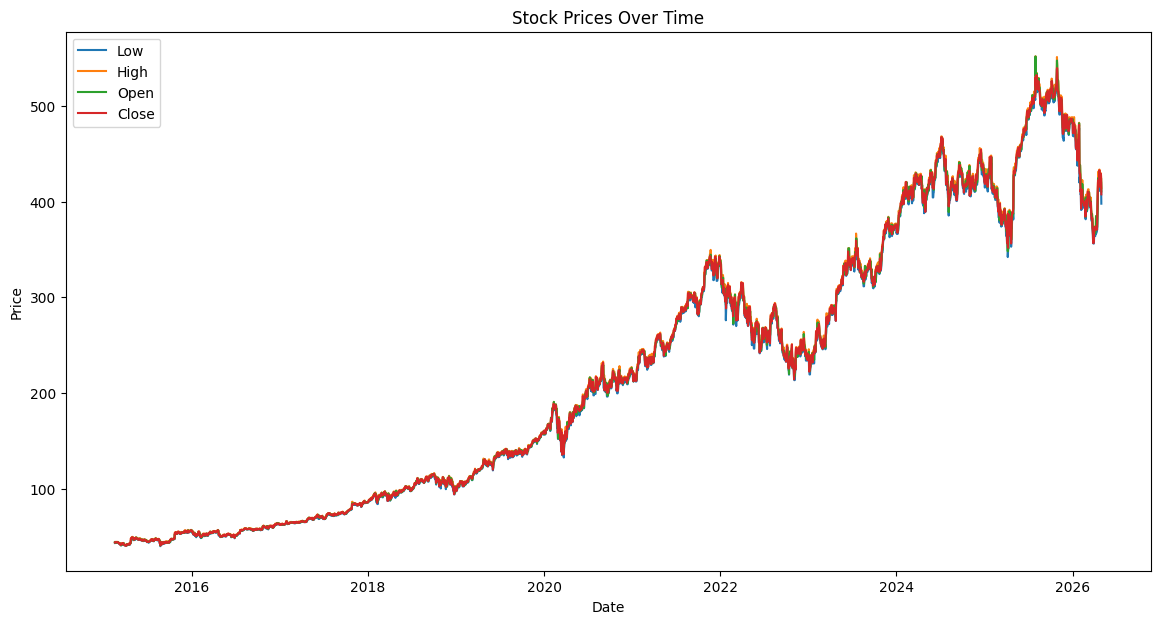

In [111]:
# plot the low, high, open, close prices over time
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Low'], label='Low')
plt.plot(df['Date'], df['High'], label='High')
plt.plot(df['Date'], df['Open'], label='Open')
plt.plot(df['Date'], df['Close'], label='Close')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Stock Prices Over Time')
plt.legend()
plt.show()

### 2.4 Preprocessing decisions

Explain the preprocessing choices you made.

**Template prompts**
- How did you handle missing values?
- How did you encode categorical variables?
- Did you scale numeric features?
- Did you create new features?
- Did you remove features for leakage, irrelevance, or multicollinearity?
- Did you use a time-based split instead of a random split?
- Any other preprocessing steps?

**Write-up**
> TODO


In [89]:
def engineer_features(df: pd.DataFrame, threshold: float = 0.01) -> pd.DataFrame:
    """Engineer scale-invariant features for MSFT direction prediction.

    All features use only data available at market close on day t,
    preventing any lookahead bias into day t+1.

    Parameters
    ----------
    df : pd.DataFrame
        Raw MSFT dataframe with Date, Open, High, Low, Close, Volume columns.
    threshold : float
        Neutral zone threshold for target creation (default 0.5%).

    Returns
    -------
    pd.DataFrame
        Feature-engineered dataframe with binary target column.
        Neutral days are dropped.
    """
    import logging
    logger = logging.getLogger(__name__)

    df = df.copy()
    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']

    # --- Fractional changes (scale-invariant, replaces raw price lags) ---
    df['return_1d'] = close.pct_change(1) * 100
    df['return_5d'] = close.pct_change(5) * 100
    df['return_10d'] = close.pct_change(10) * 100

    # --- Lagged returns (yesterday and two days ago) ---
    df['lag_return_1'] = df['return_1d'].shift(1)
    df['lag_return_2'] = df['return_1d'].shift(2)

    # --- RSI(14): overbought/oversold oscillator ---
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=13, min_periods=14).mean()
    avg_loss = loss.ewm(com=13, min_periods=14).mean()
    df['rsi_14'] = 100 - (100 / (1 + avg_gain / avg_loss))

    # --- MACD: trend-following momentum oscillator ---
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    df['macd'] = ema12 - ema26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']  # positive = bullish momentum

    # --- Volatility ---
    df['price_range_pct'] = (high - low) / close * 100
    df['rolling_std_5'] = close.rolling(5).std()

    # --- Volume signal ---
    df['volume_ratio'] = volume / volume.rolling(20).mean()

    # --- 3-class target: UP (1), DOWN (0), NEUTRAL (2) ---
    next_return = (close.shift(-1) - close) / close * 100
    threshold_pct = threshold * 100
    df['Direction'] = np.where(
        next_return > threshold_pct,
        1,
        np.where(next_return < -threshold_pct, 0, 2),
    )
    # Drop only the last row where shift(-1) produces NaN (no t+1 exists)
    df = df.dropna(subset=['Direction']).copy()
    df['Direction'] = df['Direction'].astype(int)
    df = df.dropna()

    counts = df['Direction'].value_counts().sort_index()
    logger.info(
        'Target balance — DOWN(0): %d | NEUTRAL(2): %d | UP(1): %d',
        counts.get(0, 0),
        counts.get(2, 0),
        counts.get(1, 0),
    )
    return df

In [90]:
df = engineer_features(df)

In [91]:
# check and handle missing values
missing_total = df.isna().sum().sum()
print(f"Total missing values: {missing_total}")
if missing_total > 0:
    numeric_cols = df.select_dtypes(include="number").columns
    non_numeric_cols = df.columns.difference(numeric_cols)
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    for col in non_numeric_cols:
        mode_value = df[col].mode(dropna=True)
        if not mode_value.empty:
            df[col] = df[col].fillna(mode_value.iloc[0])
    print("Missing values filled.")

Total missing values: 0


In [92]:
df.head()

,Date,Open,High,Low,Close,Volume,gold_close,oil_close,vix,spy_close,is_trading_day,is_weekend,is_holiday,return_1d,return_5d,return_10d,lag_return_1,lag_return_2,rsi_14,macd,macd_signal,macd_hist,price_range_pct,rolling_std_5,volume_ratio,Direction
19,2020-01-21,166.68,168.19,166.43,166.50,29286191.0,1556.400024,58.340000,12.85,302.764374,True,False,False,-0.359066,0.198592,3.198215,0.000000,0.000000,70.713079,1.771010,1.183587,0.587423,1.057057,0.268328,1.177916,2
20,2020-01-22,167.40,167.49,165.68,165.70,24138777.0,1555.300049,56.740002,12.91,302.800842,True,False,False,-0.480480,-0.837822,2.702368,-0.359066,0.000000,64.580571,1.707127,1.288295,0.418832,1.092336,0.616441,0.967954,2
21,2020-01-23,166.19,166.80,165.27,166.72,19680766.0,1564.599976,55.590000,12.98,303.148163,True,False,False,0.615570,-0.227409,2.106810,-0.480480,-0.359066,68.349468,1.718990,1.374434,0.344556,0.917706,0.576958,0.791477,0
22,2020-01-24,167.51,167.53,164.45,165.04,24918117.0,1571.099976,54.189999,14.56,300.452271,True,False,False,-1.007678,-1.232795,1.794856,0.615570,-0.480480,57.497353,1.574677,1.414482,0.160194,1.866214,0.831457,0.994509,2
23,2020-01-25,167.51,167.53,164.45,165.04,24918117.0,1571.099976,54.189999,14.56,300.452271,False,True,False,0.000000,-1.232795,1.139846,-1.007678,0.615570,57.497353,1.443666,1.420319,0.023347,1.866214,0.790822,0.987031,2


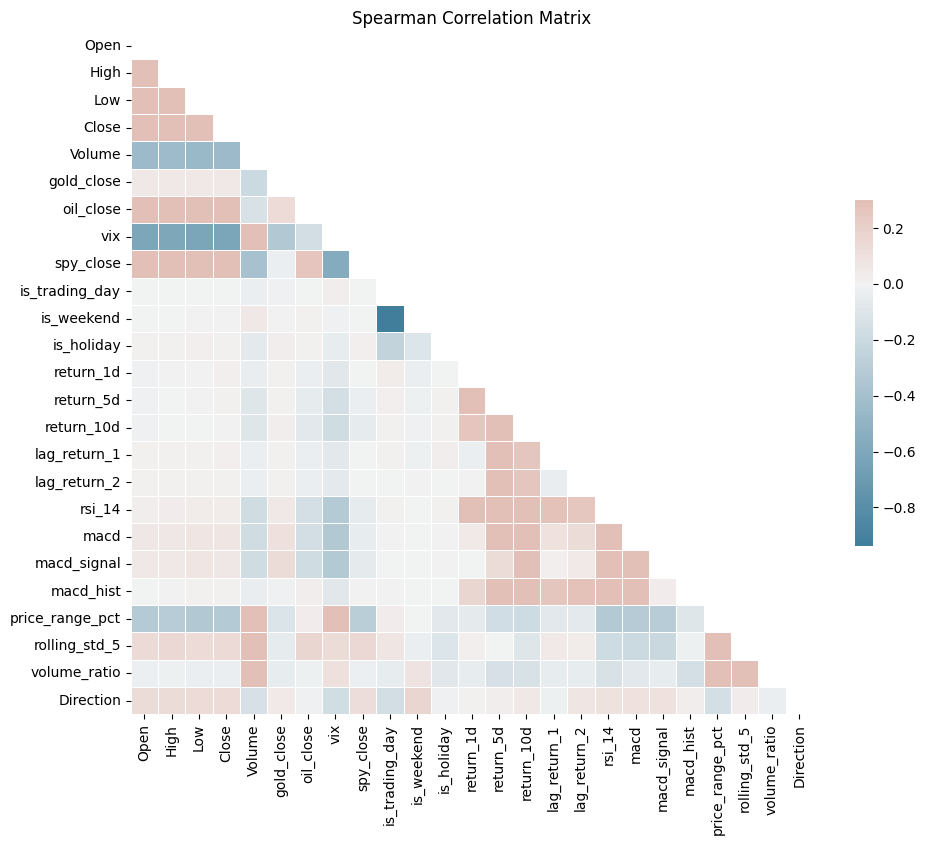

In [93]:
# Calculate the correlation matrix
corr = df.iloc[:, 1:].corr(method='spearman')
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Spearman Correlation Matrix')
plt.show()

## 3. Validation strategy

State clearly how you will validate model performance.

### 3.1 Chosen validation approach
Select the method that best matches your problem:
- Train/test split
- Cross-validation
- Stratified split
- Time-based validation
- Backtesting / rolling window validation
- Group-based split

**Justification**
> TODO: explain why this validation method is appropriate for your problem and data.

### 3.2 Leakage prevention
Explain how you reduced leakage risk.

**Write-up**
> TODO


In [94]:
# split data 80/20 for train/test
from sklearn.model_selection import train_test_split

close_series = df["Close"].copy() # for ARIMA model

# Columns that are non-stationary or directly encode the target
DROP_COLS = ['Open', 'High', 'Low', 'Close', 'Volume', 'Close_prev',
             'rolling_mean_5', 'is_trading_day', 'is_weekend', 'is_holiday', 'oil_close']

FEATURE_COLUMNS = [
    'return_1d',
    'return_5d',
    'return_10d',
    'lag_return_1',
    'lag_return_2',
    'rsi_14',
    'macd',
    'macd_signal',
    'macd_hist',
    'price_range_pct',
    'rolling_std_5',
    'volume_ratio',
]

# Verify all expected columns exist
# missing_cols = [c for c in FEATURE_COLUMNS if c not in df.columns]
# if missing_cols:
#     raise ValueError(f"Missing feature columns: {missing_cols}")

# X = df.drop(['Date', 'is_trading_day','is_weekend','is_holiday', 'return_1d', 'return_5d','return_10d','lag_return_1','lag_return_2','rsi_14', 'macd', 'macd_signal','macd_hist','price_range_pct',
#  'rolling_std_5',
#  'volume_ratio', 'Direction'], axis=1) # no extra features

X = df[FEATURE_COLUMNS]
y = df['Direction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, shuffle=False  # shuffle=False preserves time order
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print("Train class balance:")
print(y_train.value_counts(normalize=True).sort_index())

Training set: 1948 samples
Test set: 344 samples
Train class balance:
Direction
0    0.154517
1    0.188912
2    0.656571
Name: proportion, dtype: float64


In [95]:
# scale features using training data only (avoid leakage)
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# full scaled dataframe for inspection (uses train-fitted scaler)
X_scaled = scaler.transform(X)
scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
scaled_df.insert(0, "Date", df["Date"].to_numpy())
scaled_df["Close"] = df["Close"].to_numpy()
scaled_df["Direction"] = df["Direction"].to_numpy()

## 4. Baseline model

A baseline gives you something simple to compare against.

### 4.1 Baseline approach
Describe the baseline and why it is a reasonable minimum benchmark.

Examples:
- Predict the most frequent class
- Predict the mean/median target
- Previous-period value for forecasting
- Simple rule-based heuristic
- Existing manual process

**Write-up**
> TODO


In [96]:
import logging
import numpy as np

logger = logging.getLogger(__name__)


def direction_from_prev(
    prev_close: np.ndarray,
    current_close: np.ndarray,
    threshold: float = 0.01,
) -> np.ndarray:
    """Convert two price series into 3-class directional labels.

    Parameters
    ----------
    prev_close : array-like
        Previous day's closing prices.
    current_close : array-like
        Current day's closing prices.
    threshold : float
        Minimum absolute percentage change to assign UP or DOWN.
        Moves within ±threshold are labelled NEUTRAL (2).

    Returns
    -------
    np.ndarray
        Array of 1 (UP), 0 (DOWN), or 2 (NEUTRAL).
    """
    prev_vals = np.asarray(prev_close)
    curr_vals = np.asarray(current_close)
    pct_change = (curr_vals - prev_vals) / prev_vals
    logger.debug(
        "direction_from_prev: %.1f%% neutral days",
        100 * np.mean(np.abs(pct_change) < threshold),
    )
    return np.where(
        pct_change >= threshold,
        1,
        np.where(pct_change <= -threshold, 0, 2),
    )

In [97]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score

baseline_clf = DummyClassifier(strategy="most_frequent")
baseline_clf.fit(X_train_scaled, y_train)
baseline_pred = baseline_clf.predict(X_test_scaled)

baseline_metrics = {
    "f1": f1_score(y_test, baseline_pred, average="macro"),
    "accuracy": accuracy_score(y_test, baseline_pred),
    "precision": precision_score(y_test, baseline_pred, average="macro", zero_division=0),
    "recall": recall_score(y_test, baseline_pred, average="macro"),
}
print("Baseline (Most Frequent Class) Performance:")
print(classification_report(
    y_test, baseline_pred,
    target_names=["DOWN", "UP", "NEUTRAL"],
    labels=[0, 1, 2],
))
baseline_metrics

Baseline (Most Frequent Class) Performance:
              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00        47
          UP       0.00      0.00      0.00        46
     NEUTRAL       0.73      1.00      0.84       251

    accuracy                           0.73       344
   macro avg       0.24      0.33      0.28       344
weighted avg       0.53      0.73      0.62       344



c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill

{'f1': 0.2812324929971989,
 'accuracy': 0.7296511627906976,
 'precision': 0.24321705426356588,
 'recall': 0.3333333333333333}

In [98]:
from statsmodels.tsa.arima.model import ARIMA

# Use the full close series, not the filtered test index
full_close = close_series  # unfiltered, all trading days

# Split at the same 80/20 boundary used for X_train/X_test
split_idx = X_train.index[-1]  # last date in training set
train_close_full = full_close.loc[:split_idx]
test_close_full = full_close.loc[split_idx:].iloc[1:]  # everything after train

arima_model = ARIMA(train_close_full, order=(5, 1, 0))
arima_fit = arima_model.fit()
arima_forecast_full = arima_fit.forecast(steps=len(test_close_full))
arima_forecast_full = pd.Series(
    arima_forecast_full.values, index=test_close_full.index
)

# Now filter to only the test rows that survived neutral-day removal
arima_forecast_filtered = arima_forecast_full.loc[X_test.index]
test_close_filtered = test_close_full.loc[X_test.index]
arima_prev_close = full_close.shift(1).loc[X_test.index]

arima_dir_true = direction_from_prev(arima_prev_close, test_close_filtered).astype(int)
arima_dir_pred = direction_from_prev(arima_prev_close, arima_forecast_filtered).astype(int)

# No mask needed — neutral days are class 2, not NaN
arima_metrics = {
    "f1": f1_score(arima_dir_true, arima_dir_pred, average="macro"),
    "accuracy": accuracy_score(arima_dir_true, arima_dir_pred),
    "precision": precision_score(arima_dir_true, arima_dir_pred, average="macro", zero_division=0),
    "recall": recall_score(arima_dir_true, arima_dir_pred, average="macro"),
}
print("ARIMA (Direction from Close Forecast) Performance:")
print(classification_report(
    arima_dir_true, arima_dir_pred,
    target_names=["DOWN", "UP", "NEUTRAL"],
    labels=[0, 1, 2],
))
arima_metrics

ARIMA (Direction from Close Forecast) Performance:
              precision    recall  f1-score   support

        DOWN       0.12      0.60      0.19        47
          UP       0.21      0.41      0.28        46
     NEUTRAL       0.56      0.02      0.04       251

    accuracy                           0.15       344
   macro avg       0.29      0.34      0.17       344
weighted avg       0.45      0.15      0.09       344



{'f1': 0.16897576852599341,
 'accuracy': 0.1511627906976744,
 'precision': 0.29243454404485,
 'recall': 0.34290282594567767}

### 4.2 Baseline results
Record the baseline performance here.

| Metric | Baseline result | Notes |
|---|---:|---|
| Primary metric | TODO | TODO |
| Secondary metric | TODO | TODO |
| Other metric | TODO | TODO |

**Interpretation**
> TODO: explain what the baseline tells you.


## 5. Candidate models

List the models you plan to try and why they are appropriate.

| Model | Why this model is suitable | Key strengths | Main risks / limitations |
|---|---|---|---|
| Random Forest | Handles nonlinear relationships and mixed signals in tabular market features | Robust, low tuning overhead | Can overfit noisy signals |
| XGBoost | Strong gradient-boosted baseline for tabular classification | High performance, handles interactions | Sensitive to tuning and leakage |
| LSTM | Captures temporal dependencies in sequential features | Learns sequence patterns | Requires more data and tuning |
| ARIMA | Time-series forecasting for close price then derive direction | Interpretable, classic baseline | Assumes linear patterns, weak on regime shifts |

**Selection rationale**
> TODO

## 6. Evaluation framework

Before training, define the metrics you will use and why.

### 6.1 Primary metric
Choose the main metric used to compare models.

**Examples**
- Classification: F1, recall, precision, ROC-AUC, PR-AUC, balanced accuracy
- Regression: RMSE, MAE, R², MAPE
- Forecasting: MAE, RMSE, sMAPE, MASE
- Ranking/recommendation: MAP@K, Recall@K, NDCG

**Justification**
> TODO

### 6.2 Secondary metrics
Add supporting metrics that capture other aspects of performance.

**Write-up**
> TODO


## 7. Train and evaluate models

Train each candidate model and compare results systematically.


In [99]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

rf_metrics = {
    "f1": f1_score(y_test, rf_pred, average="macro"),
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision": precision_score(y_test, rf_pred, average="macro", zero_division=0),
    "recall": recall_score(y_test, rf_pred, average="macro"),
}
print("Random Forest Performance:")
print(classification_report(
    y_test, rf_pred,
    target_names=["DOWN", "UP", "NEUTRAL"],
    labels=[0, 1, 2],
))
rf_metrics

Random Forest Performance:
              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00        47
          UP       0.40      0.04      0.08        46
     NEUTRAL       0.73      0.99      0.84       251

    accuracy                           0.73       344
   macro avg       0.38      0.34      0.31       344
weighted avg       0.59      0.73      0.62       344



c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill

{'f1': 0.3063697795502382,
 'accuracy': 0.7267441860465116,
 'precision': 0.37718780727630286,
 'recall': 0.3438420232115018}

In [100]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.001,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
)
xgb.fit(X_train_scaled, y_train)

xgb_pred = xgb.predict(X_test_scaled).astype(int)

xgb_metrics = {
    "f1": f1_score(y_test, xgb_pred, average="macro"),
    "accuracy": accuracy_score(y_test, xgb_pred),
    "precision": precision_score(y_test, xgb_pred, average="macro", zero_division=0),
    "recall": recall_score(y_test, xgb_pred, average="macro"),
}
print("XGBoost Performance:")
print(classification_report(
    y_test, xgb_pred,
    target_names=["DOWN", "UP", "NEUTRAL"],
    labels=[0, 1, 2],
))
xgb_metrics

XGBoost Performance:
              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00        47
          UP       0.00      0.00      0.00        46
     NEUTRAL       0.73      1.00      0.84       251

    accuracy                           0.73       344
   macro avg       0.24      0.33      0.28       344
weighted avg       0.53      0.73      0.62       344



c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill

{'f1': 0.2812324929971989,
 'accuracy': 0.7296511627906976,
 'precision': 0.24321705426356588,
 'recall': 0.3333333333333333}

---
ARIMA model


### 7.1 Model comparison summary

| Model | Primary metric | Secondary metrics | Better than baseline? | Notes |
|---|---:|---|---|---|
| Baseline | TODO | TODO | — | TODO |
| Model 1 | TODO | TODO | TODO | TODO |
| Model 2 | TODO | TODO | TODO | TODO |
| Model 3 | TODO | TODO | TODO | TODO |

**Interpretation**
> TODO: explain which model(s) look most promising and why.


In [103]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)
np.random.seed(42)



seq_len = 10
X_all = X_scaled
Y_all = y.to_numpy()

train_size = len(X_train)
train_positions = np.arange(train_size)
test_positions = np.arange(train_size, len(X_all))

def make_sequences(positions, X_array, y_array, window):
    X_seq = []
    y_seq = []
    for pos in positions:
        if pos - window < 0:
            continue
        X_seq.append(X_array[pos - window:pos])
        y_seq.append(y_array[pos])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = make_sequences(train_positions, X_all, Y_all, seq_len)
X_test_seq, y_test_seq = make_sequences(test_positions, X_all, Y_all, seq_len)

w = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=y_train_seq)
class_weight_dict = {i: w[i] for i in range(3)}

lstm_model = models.Sequential(
    [
        layers.Input(shape=(seq_len, X_all.shape[1])),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(32, return_sequences=False),
        layers.Dropout(0.3),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(3, activation="softmax"),  # 3 classes: DOWN, UP, NEUTRAL
    ]
)

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",  # works directly with integer labels
    metrics=["accuracy"],
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,

)

lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)

lstm_proba = lstm_model.predict(X_test_seq, verbose=0)  # shape: (n, 3)
lstm_pred = np.argmax(lstm_proba, axis=1)               # 0, 1, or 2

lstm_metrics = {
    "f1": f1_score(y_test_seq, lstm_pred, average="macro"),
    "accuracy": accuracy_score(y_test_seq, lstm_pred),
    "precision": precision_score(y_test_seq, lstm_pred, average="macro", zero_division=0),
    "recall": recall_score(y_test_seq, lstm_pred, average="macro"),
}
print("LSTM Performance:")
print(classification_report(
    y_test_seq, lstm_pred,
    target_names=["DOWN", "UP", "NEUTRAL"],
    labels=[0, 1, 2],
))
lstm_metrics

LSTM Performance:
              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00        47
          UP       0.00      0.00      0.00        46
     NEUTRAL       0.73      1.00      0.84       251

    accuracy                           0.73       344
   macro avg       0.24      0.33      0.28       344
weighted avg       0.53      0.73      0.62       344



c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill

{'f1': 0.2812324929971989,
 'accuracy': 0.7296511627906976,
 'precision': 0.24321705426356588,
 'recall': 0.3333333333333333}

In [20]:
model_results = pd.DataFrame(
    [
        {"model": "Random Forest", **rf_metrics},
        {"model": "XGBoost", **xgb_metrics},
        {"model": "ARIMA", **arima_metrics},
        {"model": "LSTM", **lstm_metrics},
    ]
).set_index("model")

model_results

,f1,accuracy,precision,recall
model,,,,
Random Forest,0.479527,0.624,0.389376,0.624
XGBoost,0.479527,0.624,0.389376,0.624
ARIMA,0.147527,0.232,0.504171,0.232
LSTM,0.479527,0.624,0.389376,0.624


In [ ]:
# No ML algorithm used in this approach.

In [ ]:
# No ML algorithm used in this approach.

In [ ]:
# No ML algorithm used in this approach.

## 8. Iteration and improvement

This section should show how you refined your approach over time.

Typical improvements:
- alternative algorithms
- hyperparameter tuning
- feature engineering
- better preprocessing
- class balancing
- threshold tuning
- regularisation changes
- better handling of missing data
- different validation setup

Record each meaningful iteration.


In [ ]:
import optuna
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)

def rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "class_weight": "balanced",
        "random_state": 42,
    }

    scores = []
    for train_idx, val_idx in tscv.split(X_train_scaled):
        model = RandomForestClassifier(**params)
        model.fit(X_train_scaled[train_idx], y_train.iloc[train_idx])
        preds = model.predict(X_train_scaled[val_idx])
        scores.append(f1_score(y_train.iloc[val_idx], preds, average="macro"))
    return float(np.mean(scores))

rf_study = optuna.create_study(direction="maximize")
rf_study.optimize(rf_objective, n_trials=20)

rf_best_params = rf_study.best_params
rf_best_score = rf_study.best_value
rf_best_params, rf_best_score

c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-05 15:14:52,212] A new study created in memory with name: no-name-2327ab6f-06eb-4b7f-8434-c12edcf8e0c2
[I 2026-06-05 15:14:53,999] Trial 0 finished with value: 0.523152062811473 and parameters: {'n_estimators': 302, 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.523152062811473.
[I 2026-06-05 15:14:55,019] Trial 1 finished with value: 0.5541876342432904 and parameters: {'n_estimators': 168, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.5541876342432904.
[I 2026-06-05 15:14:56,163] Trial 2 finished with value: 0.6346685029248142 and parameters: {'n_estimators': 165

({'n_estimators': 436,
  'max_depth': 13,
  'min_samples_split': 7,
  'min_samples_leaf': 1},
 0.6384852596129673)

In [ ]:
def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "objective": "multi:softmax",
        "num_class": 3,
        "eval_metric": "mlogloss",
        "random_state": 42,
    }

    scores = []
    for train_idx, val_idx in tscv.split(X_train_scaled):
        model = XGBClassifier(**params)
        model.fit(X_train_scaled[train_idx], y_train.iloc[train_idx])
        preds = model.predict(X_train_scaled[val_idx]).astype(int)
        scores.append(f1_score(y_train.iloc[val_idx], preds, average="macro"))
    return float(np.mean(scores))

xgb_study = optuna.create_study(direction="maximize")
xgb_study.optimize(xgb_objective, n_trials=20)

xgb_best_params = xgb_study.best_params
xgb_best_score = xgb_study.best_value
xgb_best_params, xgb_best_score

[I 2026-06-05 15:15:41,760] A new study created in memory with name: no-name-17fd5766-c63e-4c32-aad4-cf962d0c6144
[I 2026-06-05 15:15:43,446] Trial 0 finished with value: 0.6272764610863418 and parameters: {'n_estimators': 288, 'max_depth': 6, 'learning_rate': 0.02935312688872615, 'subsample': 0.689727146640182, 'colsample_bytree': 0.872990221056804}. Best is trial 0 with value: 0.6272764610863418.
[I 2026-06-05 15:15:45,510] Trial 1 finished with value: 0.631204796379394 and parameters: {'n_estimators': 314, 'max_depth': 7, 'learning_rate': 0.010112021077064182, 'subsample': 0.9592526191899984, 'colsample_bytree': 0.9149088322116383}. Best is trial 1 with value: 0.631204796379394.
[I 2026-06-05 15:15:46,554] Trial 2 finished with value: 0.6379317346525147 and parameters: {'n_estimators': 199, 'max_depth': 7, 'learning_rate': 0.014799846777380058, 'subsample': 0.6253135320780832, 'colsample_bytree': 0.6655419157240668}. Best is trial 2 with value: 0.6379317346525147.
[I 2026-06-05 15:1

({'n_estimators': 194,
  'max_depth': 6,
  'learning_rate': 0.01863354426965134,
  'subsample': 0.6087491119635776,
  'colsample_bytree': 0.6638151333675429},
 0.64939565635783)

In [ ]:
def build_lstm_model(input_shape, units, dropout, learning_rate):
    """Build an LSTM model for 3-class direction classification.

    Parameters
    ----------
    input_shape : tuple
        Shape of one input sequence (seq_len, n_features).
    units : int
        Number of LSTM units.
    dropout : float
        Dropout rate after the LSTM layer.
    learning_rate : float
        Adam optimiser learning rate.

    Returns
    -------
    tf.keras.Model
        Compiled Keras model outputting softmax probabilities over 3 classes.
    """
    # model = models.Sequential(
    #     [
    #         layers.Input(shape=input_shape),
    #         layers.LSTM(units, return_sequences=False),
    #         layers.Dropout(dropout),
    #         layers.Dense(32, activation="relu"),
    #         layers.Dense(3, activation="softmax"),  # 3 classes: DOWN, UP, NEUTRAL
    #     ]
    # ) old model

    model = models.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(dropout),
        layers.LSTM(32, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(16, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(8, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(3, activation="softmax"),  # 3 classes: DOWN, UP, NEUTRAL
    ]
)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

lstm_tscv = TimeSeriesSplit(n_splits=3)

def lstm_objective(trial):
    seq_len_trial = trial.suggest_int("seq_len", 5, 30)
    units = trial.suggest_int("units", 32, 128)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    scores = []
    for train_idx, val_idx in lstm_tscv.split(X_train_scaled):
        X_train_fold = X_train_scaled[train_idx]
        y_train_fold = y_train.iloc[train_idx].to_numpy()
        X_val_fold = X_train_scaled[val_idx]
        y_val_fold = y_train.iloc[val_idx].to_numpy()

        X_train_seq, y_train_seq = make_sequences(
            np.arange(len(X_train_fold)),
            X_train_fold,
            y_train_fold,
            seq_len_trial,
        )
        X_val_seq, y_val_seq = make_sequences(
            np.arange(len(X_val_fold)),
            X_val_fold,
            y_val_fold,
            seq_len_trial,
        )

        if len(X_train_seq) == 0 or len(X_val_seq) == 0:
            continue

        tf.keras.backend.clear_session()
        model = build_lstm_model(
            input_shape=(seq_len_trial, X_train_fold.shape[1]),
            units=units,
            dropout=dropout,
            learning_rate=learning_rate,
        )
        model.fit(
            X_train_seq,
            y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=15,
            batch_size=batch_size,
            verbose=0,
        )
        val_proba = model.predict(X_val_seq, verbose=0)  # shape: (n, 3)
        val_pred = np.argmax(val_proba, axis=1)
        scores.append(f1_score(y_val_seq, val_pred, average="macro"))

    if not scores:
        return 0.0
    return float(np.mean(scores))

lstm_study = optuna.create_study(direction="maximize")
lstm_study.optimize(lstm_objective, n_trials=10)

lstm_best_params = lstm_study.best_params
lstm_best_score = lstm_study.best_value
lstm_best_params, lstm_best_score

[I 2026-06-05 15:16:24,060] A new study created in memory with name: no-name-3d309788-5307-42e2-8c87-9e1a059424d9


[I 2026-06-05 15:16:48,291] Trial 0 finished with value: 0.6334835652349263 and parameters: {'seq_len': 5, 'units': 113, 'dropout': 0.40115388752245085, 'learning_rate': 0.004434450846676633, 'batch_size': 64}. Best is trial 0 with value: 0.6334835652349263.
[I 2026-06-05 15:17:16,178] Trial 1 finished with value: 0.6417427038859936 and parameters: {'seq_len': 22, 'units': 56, 'dropout': 0.46105056591574234, 'learning_rate': 0.0006699169214040749, 'batch_size': 32}. Best is trial 1 with value: 0.6417427038859936.
[I 2026-06-05 15:17:49,121] Trial 2 finished with value: 0.6339380019320122 and parameters: {'seq_len': 19, 'units': 59, 'dropout': 0.31684206377099816, 'learning_rate': 0.0002092033575490391, 'batch_size': 16}. Best is trial 1 with value: 0.6417427038859936.
[I 2026-06-05 15:18:21,453] Trial 3 finished with value: 0.6350324202432658 and parameters: {'seq_len': 10, 'units': 36, 'dropout': 0.17881063103795347, 'learning_rate': 0.006927443826002928, 'batch_size': 32}. Best is tr

({'seq_len': 22,
  'units': 56,
  'dropout': 0.46105056591574234,
  'learning_rate': 0.0006699169214040749,
  'batch_size': 32},
 0.6417427038859936)

In [24]:
tuned_summary = pd.DataFrame(
    [
        {"model": "Random Forest", "cv_f1": rf_best_score, **rf_best_params},
        {"model": "XGBoost", "cv_f1": xgb_best_score, **xgb_best_params},
        {"model": "LSTM", "cv_f1": lstm_best_score, **lstm_best_params},
    ]
).set_index("model")

tuned_summary

,cv_f1,n_estimators,max_depth,min_samples_split,min_samples_leaf,learning_rate,subsample,colsample_bytree,seq_len,units,dropout,batch_size
model,,,,,,,,,,,,
Random Forest,0.638485,436.0,13.0,7.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
XGBoost,0.649396,194.0,6.0,NaN,NaN,0.018634,0.608749,0.663815,NaN,NaN,NaN,NaN
LSTM,0.641743,NaN,NaN,NaN,NaN,0.000670,NaN,NaN,22.0,56.0,0.461051,32.0


In [ ]:
# Refit tuned models on full training split
rf_tuned = RandomForestClassifier(**rf_best_params, class_weight="balanced", random_state=42)
rf_tuned.fit(X_train_scaled, y_train)

xgb_tuned = XGBClassifier(**xgb_best_params, objective="multi:softmax", num_class=3, eval_metric="mlogloss", random_state=42)
xgb_tuned.fit(X_train_scaled, y_train)

# LSTM refit uses best params for the original train split
best_seq_len = lstm_best_params.get("seq_len", seq_len)
X_train_seq_best, y_train_seq_best = make_sequences(train_positions, X_all, Y_all, best_seq_len)
X_test_seq_best, y_test_seq_best = make_sequences(test_positions, X_all, Y_all, best_seq_len)

lstm_tuned = build_lstm_model(
    input_shape=(best_seq_len, X_all.shape[1]),
    units=lstm_best_params.get("units", 64),
    dropout=lstm_best_params.get("dropout", 0.2),
    learning_rate=lstm_best_params.get("learning_rate", 0.001),
)
lstm_tuned.fit(
    X_train_seq_best,
    y_train_seq_best,
    validation_split=0.2,
    epochs=20,
    batch_size=lstm_best_params.get("batch_size", 32),
    verbose=0,
)

rf_tuned_pred = rf_tuned.predict(X_test_scaled)
xgb_tuned_pred = xgb_tuned.predict(X_test_scaled).astype(int)
lstm_tuned_pred = np.argmax(lstm_tuned.predict(X_test_seq_best, verbose=0), axis=1)

rf_tuned_metrics = {
    "f1": f1_score(y_test, rf_tuned_pred, average="macro"),
    "accuracy": accuracy_score(y_test, rf_tuned_pred),
    "precision": precision_score(y_test, rf_tuned_pred, average="macro", zero_division=0),
    "recall": recall_score(y_test, rf_tuned_pred, average="macro"),
}

xgb_tuned_metrics = {
    "f1": f1_score(y_test, xgb_tuned_pred, average="macro"),
    "accuracy": accuracy_score(y_test, xgb_tuned_pred),
    "precision": precision_score(y_test, xgb_tuned_pred, average="macro", zero_division=0),
    "recall": recall_score(y_test, xgb_tuned_pred, average="macro"),
}

lstm_tuned_metrics = {
    "f1": f1_score(y_test_seq_best, lstm_tuned_pred, average="macro"),
    "accuracy": accuracy_score(y_test_seq_best, lstm_tuned_pred),
    "precision": precision_score(y_test_seq_best, lstm_tuned_pred, average="macro", zero_division=0),
    "recall": recall_score(y_test_seq_best, lstm_tuned_pred, average="macro"),
}
pd.DataFrame(
    [
        {"model": "Random Forest (tuned)", **rf_tuned_metrics},
        {"model": "XGBoost (tuned)", **xgb_tuned_metrics},
        {"model": "LSTM (tuned)", **lstm_tuned_metrics},
    ]
).set_index("model")

,f1,accuracy,precision,recall
model,,,,
Random Forest (tuned),0.502892,0.592,0.443259,0.592
XGBoost (tuned),0.494605,0.616,0.435321,0.616
LSTM (tuned),0.479527,0.624,0.389376,0.624


In [26]:
print(classification_report(
    y_test, lstm_tuned_pred,
    target_names=["DOWN", "UP", "NEUTRAL"],
    labels=[0, 1, 2],
))

              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00        24
          UP       0.00      0.00      0.00        23
     NEUTRAL       0.62      1.00      0.77        78

    accuracy                           0.62       125
   macro avg       0.21      0.33      0.26       125
weighted avg       0.39      0.62      0.48       125



c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\angel\AppData\Local\pypoetry\Cache\virtualenvs\2025-26d-fai1-adsai-group-15-Gmc8at2I-py3.13\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill

In [ ]:
# ARIMA is not tuned per requirement. It remains the baseline time-series model for direction.

### 8.1 Iteration log

Duplicate rows as needed.

| Iteration | Change made | Reason for change | Result | Decision |
|---|---|---|---|---|
| 1 | TODO | TODO | TODO | TODO |
| 2 | TODO | TODO | TODO | TODO |
| 3 | TODO | TODO | TODO | TODO |

### 8.2 What improved performance?
> TODO

### 8.3 What did not help?
> TODO


## 9. Error analysis

Go beyond summary metrics and inspect where the model fails.

### 9.1 Questions to answer
- Which examples are commonly misclassified or badly predicted?
- Are errors concentrated in specific classes, ranges, segments, or time periods?
- Are there data quality issues causing errors?
- Are some features misleading or unstable?
- Are there fairness or subgroup performance concerns?

### 9.2 Error analysis write-up
> TODO


In [ ]:
# TODO: inspect predictions and errors



In [ ]:
# TODO: create an error analysis table



## 10. Validation results

Summarise how the chosen model performed under the selected validation method.

### 10.1 Validation approach used
> TODO

### 10.2 Validation results
| Metric | Validation result | Interpretation |
|---|---:|---|
| Primary metric | TODO | TODO |
| Secondary metric | TODO | TODO |
| Secondary metric | TODO | TODO |

### 10.3 Robustness and limitations
Discuss uncertainty and known weaknesses.

**Template prompts**
- How stable were results across folds or time periods?
- Is the model likely to generalise?
- What important limitations remain?
- What common errors were observed?
- Under what conditions might the model fail?

**Write-up**
> TODO


import pandas_market_calendars as mcal

df['Date'] = pd.to_datetime(df['Date']).dt.normalize()
df = df.sort_values('Date')

# Expand to daily calendar days and flag trading vs non-trading days
calendar = mcal.get_calendar('NYSE')
full_range = pd.date_range(df['Date'].min(), df['Date'].max(), freq='D')

trading_days = calendar.valid_days(start_date=full_range.min(), end_date=full_range.max())
trading_days = trading_days.tz_convert(None).normalize()

df = df.set_index('Date').reindex(full_range)
df.index.name = 'Date'
df['is_trading_day'] = df.index.normalize().isin(trading_days)
df['is_weekend'] = df.index.dayofweek >= 5
df['is_holiday'] = (~df['is_trading_day']) & (~df['is_weekend'])

# Forward fill market values for non-trading days
df = df.sort_index().ffill().reset_index()